# RQ1 – Comparing the "quality" of PRs between humans and AI

**RQ1.** Compare the quality of a pull request authored by a human versus by an AI, based on:

1. **PR size**
   - total additions  
   - total deletions  
   - churn = additions + deletions  
   - number of files touched  

2. **Additions–Deletions correlation**
   - helps evaluate whether the PR is stable (small, localized changes) or intrusive (large, disruptive changes)

3. **Amount of PR reviews**
   - number of review comments  
   - presence of `changes_requested` reviews  


In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from huggingface_hub import hf_hub_download

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [43]:
human_df = pd.read_csv("human_prs_enriched_f.csv")  # path to your CSV
human_df["agent"] = "Human"
human_df["source_type"] = "Human"
print(len(human_df), "human PRs")
human_df.head()


6618 human PRs


,id,number,title,user,user_id,state,created_at,closed_at,merged_at,repo_url,html_url,body,agent,additions,deletions,changed_files,commit_count,review_count,comment_count,reviewer_count_ui,source_type
0,2336888723,85268,feat(aci): add automations index page,ameliahsu,55610339,closed,2025-02-14T19:04:59Z,2025-02-18T22:42:20Z,2025-02-18T22:42:19Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/85268,https://sentry-j41gpomr5.sentry.dev/automation...,Human,329.0,13.0,5.0,2.0,4.0,1.0,2.0,Human
1,2447123365,89131,ref(insights): Make use of `<FeatureBadge>` fo...,ryan953,187460,closed,2025-04-08T23:29:50Z,2025-04-09T15:56:55Z,2025-04-09T15:56:54Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/89131,Using the premade component reduces an import ...,Human,4.0,5.0,2.0,2.0,1.0,3.0,1.0,Human
2,2438086945,88748,:bug: fix: update how we fetch workflow_id and...,iamrajjoshi,33237075,closed,2025-04-03T21:36:59Z,2025-04-04T15:10:57Z,2025-04-04T15:10:57Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/88748,i realized i made a mistake for how i fetch th...,Human,24.0,8.0,4.0,4.0,2.0,0.0,1.0,Human
3,2265431531,83085,fix(org-stats): Require project membership,ArthurKnaus,7033940,closed,2025-01-08T07:47:13Z,2025-01-08T08:49:40Z,2025-01-08T08:49:40Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/83085,### Problem\n\nIf the user is not member of an...,Human,77.0,43.0,2.0,1.0,1.0,0.0,1.0,Human
4,2332333882,85102,ref(consumers): Rename parallel -> batched-par...,evanpurkhiser,1421724,closed,2025-02-12T21:24:17Z,2025-02-12T22:20:33Z,2025-02-12T22:20:33Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/85102,Both crons and uptime consumers have a paralle...,Human,17.0,9.0,5.0,1.0,1.0,1.0,1.0,Human


In [44]:
BASE = "hf://datasets/hao-li/AIDev"

# PR metadata (AI agents)
pr_df = pd.read_parquet(f"{BASE}/pull_request.parquet")
pr_df = pr_df.rename(columns={"id": "pr_id"})

# Reviews
pr_reviews_df = pd.read_parquet(f"{BASE}/pr_reviews.parquet")
pr_review_comments_df = pd.read_parquet(f"{BASE}/pr_review_comments_v2.parquet")

# Commits & patch details
pr_commits_df = pd.read_parquet(f"{BASE}/pr_commits.parquet")

# Load pr_commit_details using download workaround
local_details_path = hf_hub_download(
    repo_id="hao-li/AIDev",
    filename="pr_commit_details.parquet",
    repo_type="dataset",
)
pr_commit_details_df = pd.read_parquet(local_details_path)

print("AI PR data loaded")


AI PR data loaded


In [45]:
pr_df["agent"].value_counts()
pr_commit_details_df.head()


,sha,pr_id,author,committer,message,commit_stats_total,commit_stats_additions,commit_stats_deletions,filename,status,additions,deletions,changes,patch
0,2f9d54dda4f0c87c19e0bbeb9936f525d0587e16,3271196926,devin-ai-integration[bot],devin-ai-integration[bot],Add llms.txt compilation system for AI model d...,23008,23008,0,.github/workflows/compile-llms-txt.yml,added,38.0,0.0,38.0,"@@ -0,0 +1,38 @@\n+name: Compile llms.txt\n+\n..."
1,2f9d54dda4f0c87c19e0bbeb9936f525d0587e16,3271196926,devin-ai-integration[bot],devin-ai-integration[bot],Add llms.txt compilation system for AI model d...,23008,23008,0,docs/compile_llms_txt.py,added,47.0,0.0,47.0,"@@ -0,0 +1,47 @@\n+import os\n+from pathlib im..."
2,2f9d54dda4f0c87c19e0bbeb9936f525d0587e16,3271196926,devin-ai-integration[bot],devin-ai-integration[bot],Add llms.txt compilation system for AI model d...,23008,23008,0,llms.txt,added,22923.0,0.0,22923.0,None
3,dbd1b5f129f7cffa5ce284d7255814c98bcc38a2,3271196926,devin-ai-integration[bot],devin-ai-integration[bot],Fix lint issues: remove unused variable and ap...,35,18,17,docs/compile_llms_txt.py,modified,18.0,17.0,35.0,"@@ -1,47 +1,48 @@\n import os\n from pathlib i..."
4,c2659cfdedf666c8f14753d71664563c2a932b23,3271196926,devin-ai-integration[bot],devin-ai-integration[bot],Update llms.txt to follow official standard wi...,23035,89,22946,docs/compile_llms_txt.py,modified,51.0,36.0,87.0,"@@ -3,45 +3,60 @@\n \n \n def compile_llms_txt..."


In [46]:
patch_stats = (
    pr_commit_details_df
    .groupby("pr_id")
    .agg(
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        changed_files=("filename", "nunique")
    )
    .reset_index()
)


In [47]:
commit_stats = (
    pr_commits_df
    .groupby("pr_id")
    .size()
    .rename("commit_count")
    .reset_index()
)



In [48]:
review_to_pr = pr_reviews_df[["id", "pr_id"]].rename(
    columns={"id": "pull_request_review_id", "pr_id": "pr_id"}
)
comments_mapped = pr_review_comments_df.merge(review_to_pr, on="pull_request_review_id", how="left")


In [49]:
review_stats = (
    pr_reviews_df
    .groupby("pr_id")
    .agg(
        review_count=("id","count"),
        reviewer_count=("user", lambda x: x.nunique())
    )
    .reset_index()
)

comment_stats = (
    comments_mapped
    .groupby("pr_id")
    .size()
    .rename("comment_count")
    .reset_index()
)


In [50]:
ai_df = (
    pr_df[["pr_id", "agent"]]
    .merge(patch_stats, on="pr_id", how="left")
    .merge(commit_stats, on="pr_id", how="left")
    .merge(review_stats, on="pr_id", how="left")
    .merge(comment_stats, on="pr_id", how="left")
)

# add derived metrics
ai_df["source_type"] = "AI_Agent"
ai_df["churn"] = ai_df["additions"] + ai_df["deletions"]
ai_df["new_code_fraction"] = ai_df["additions"] / ai_df["churn"].replace({0: np.nan})
ai_df["add_del_corr_proxy"] = (ai_df["additions"] - ai_df["deletions"]) / ai_df["churn"].replace({0: np.nan})

ai_df.head()


,pr_id,agent,additions,deletions,changed_files,commit_count,review_count,reviewer_count,comment_count,source_type,churn,new_code_fraction,add_del_corr_proxy
0,3264933329,Claude_Code,394.0,2.0,3.0,1.0,NaN,NaN,NaN,AI_Agent,396.0,0.994949,0.989899
1,3265118634,Claude_Code,38.0,38.0,11.0,1.0,NaN,NaN,NaN,AI_Agent,76.0,0.500000,0.000000
2,3265640341,Claude_Code,298.0,109.0,5.0,6.0,2.0,2.0,2.0,AI_Agent,407.0,0.732187,0.464373
3,3265709660,Claude_Code,288.0,12.0,15.0,3.0,1.0,1.0,2.0,AI_Agent,300.0,0.960000,0.920000
4,3265782173,Claude_Code,53.0,168.0,21.0,1.0,NaN,NaN,NaN,AI_Agent,221.0,0.239819,-0.520362


In [51]:
# Drop unwanted column
if "Unnamed: 0" in human_df.columns:
    human_df = human_df.drop(columns=["Unnamed: 0"])

# Fix reviewer_count column
human_df = human_df.rename(columns={"reviewer_count_ui": "reviewer_count"})

# Add missing derived metrics
human_df["churn"] = human_df["additions"] + human_df["deletions"]
human_df["new_code_fraction"] = human_df["additions"] / human_df["churn"].replace({0: np.nan})
human_df["add_del_corr_proxy"] = (human_df["additions"] - human_df["deletions"]) / human_df["churn"].replace({0: np.nan})


In [52]:
common_cols = [
    "additions","deletions","changed_files","commit_count",
    "review_count","comment_count","reviewer_count",
    "churn","new_code_fraction","add_del_corr_proxy",
    "agent","source_type"
]
combined = pd.concat([
    human_df[common_cols],
    ai_df[common_cols]
], ignore_index=True)

print("Combined dataset:", len(combined), "PRs")
combined.head()


Combined dataset: 40214 PRs


,additions,deletions,changed_files,commit_count,review_count,comment_count,reviewer_count,churn,new_code_fraction,add_del_corr_proxy,agent,source_type
0,329.0,13.0,5.0,2.0,4.0,1.0,2.0,342.0,0.961988,0.923977,Human,Human
1,4.0,5.0,2.0,2.0,1.0,3.0,1.0,9.0,0.444444,-0.111111,Human,Human
2,24.0,8.0,4.0,4.0,2.0,0.0,1.0,32.0,0.750000,0.500000,Human,Human
3,77.0,43.0,2.0,1.0,1.0,0.0,1.0,120.0,0.641667,0.283333,Human,Human
4,17.0,9.0,5.0,1.0,1.0,1.0,1.0,26.0,0.653846,0.307692,Human,Human


In [ ]:
attributes = [
    "additions", "deletions", "changed_files", "commit_count",
    "review_count", "comment_count", "reviewer_count",
    "churn", "new_code_fraction", "add_del_corr_proxy"
]

#min-max normalize
combined[attributes] = (
    combined[attributes] - combined[attributes].min()
) / (combined[attributes].max() - combined[attributes].min())

scores_df = pd.DataFrame(index=combined.index)

#categorize into quarters, smallest quarter is always rated the highest
for agent in combined["agent"].unique():
    mask = combined["agent"] == agent
    subset = combined.loc[mask, attributes]

    for attribute in attributes:
        quartiles = pd.qcut(subset[attribute], q=4, duplicates="drop")
        
        scored = quartiles.cat.codes.max() - quartiles.cat.codes + 1
        
        scores_df.loc[mask, attribute] = scored

scores_df["pr_quality_score"] = scores_df[attributes].sum(axis=1)

#score every PR
agents_dfs = {}
for agent in combined["agent"].unique():
    df_agent = combined[combined["agent"] == agent].copy()
    
    df_agent["pr_quality_score"] = scores_df.loc[df_agent.index, "pr_quality_score"]
    
    agents_dfs[agent] = df_agent

average_scores = {}

#rate the agents
for agent, df in agents_dfs.items():
    avg_score = df["pr_quality_score"].mean()
    average_scores[agent] = avg_score
    print(f"{agent}: {avg_score:.2f}")


In [53]:
metrics = [
    "additions","deletions","churn",
    "changed_files","commit_count",
    "review_count","comment_count","reviewer_count",
    "new_code_fraction","add_del_corr_proxy"
]

summary = combined.groupby("agent")[metrics].agg(["count","mean","median","std"])
summary


additions                                   deletions                                    churn                                   changed_files                                \
                 count         mean median           std     count         mean median           std  count         mean median           std         count       mean median         std   
agent                                                                                                                                                                                       
Claude_Code        458  6370.897380  577.0  26458.164293       458  2276.054585   74.0  16011.825653    458  8646.951965  691.0  38948.166887           458  34.137555    8.0   67.868845   
Copilot           4967  3434.610630  127.0  28075.322374      4967  2104.300383   21.0  23607.136631   4967  5538.911013  179.0  47675.631104          4967  26.836118    4.0   85.266641   
Cursor            1540  1856.870779  201.0   7301.329581      1540  1004.754545   40.0   5118.920258   1540  2861.625325  271.5  11310.089227          1540  18.357792    4.0   54.869506   
Devin             4822  1699.096226  117.5  11428.910182      4822   981.682082   27.0  10214.949689   4822  2680.778308  167.0  16678.170234          4822  26.556823    4.0   76.028630   
Human             4928  1132.195617   34.0  25527.390650      4928  1013.527192    9.0  31937.703076   4928  2145.722808   56.0  41129.134910          4928  26.054992    3.0  550.141319   
OpenAI_Codex     21793   558.305557   59.0   3701.987662     21793   242.582481    6.0   2342.592824  21793   800.888037   74.0   5241.733899         21793  12.419355    3.0   36.904790   

             commit_count                             review_count                            comment_count                             reviewer_count                            new_code_fraction  \
                    count      mean median        std        count      mean median       std         count      mean median        std          count      mean median       std             count   
agent                                                                                                                                                                                                 
Claude_Code           458  6.072052    3.0   7.618735          191  3.392670    2.0  3.650198           127  9.440945    4.0  17.231226            191  1.680628    1.0  0.982795               457   
Copilot              4967  4.794242    3.0   4.491719         2682  5.996271    3.0  6.648133          1682  9.070155    6.0  10.299319           2682  2.340045    2.0  1.190206              4500   
Cursor               1540  4.008442    2.0   4.939457          772  2.314767    1.0  2.697578           352  4.218750    2.0   4.912382            772  1.409326    1.0  0.719068              1539   
Devin                4822  4.828080    3.0   5.818425         2147  2.669772    2.0  2.925517          1171  4.276687    2.0   5.348884           2147  1.418258    1.0  0.692929              4803   
Human                4928  5.857346    2.0  21.926389         4928  1.860187    1.0  4.495824          4928  1.742289    1.0   3.081753           4928  1.627435    1.0  2.333385              4899   
OpenAI_Codex        21793  1.492589    1.0   2.301948         2348  1.970187    1.0  2.241104          1133  3.459841    2.0   4.450099           2348  1.390545    1.0  0.798078             21779   

                                           add_del_corr_proxy                                
                  mean    median       std              count      mean    median       std  
agent                                                                                        
Claude_Code   0.776979  0.827586  0.203543                457  0.553958  0.655172  0.407087  
Copilot       0.716254  0.727825  0.226176               4500  0.432508  0.455649  0.452352  
Cursor        0.708462  0.711111  0.225067       

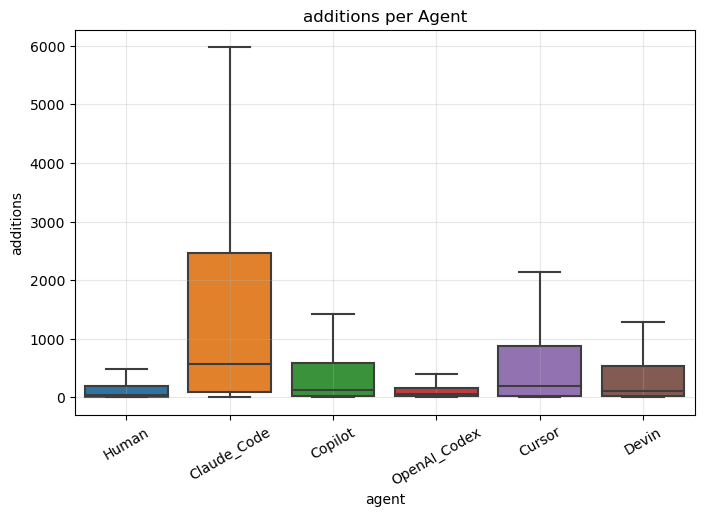

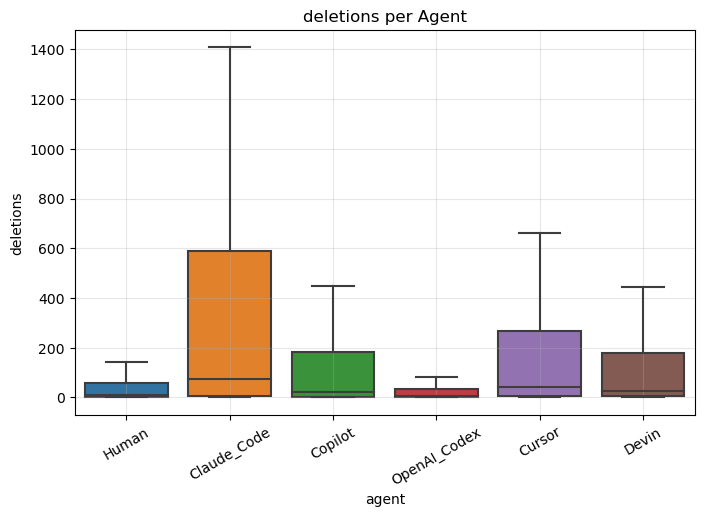

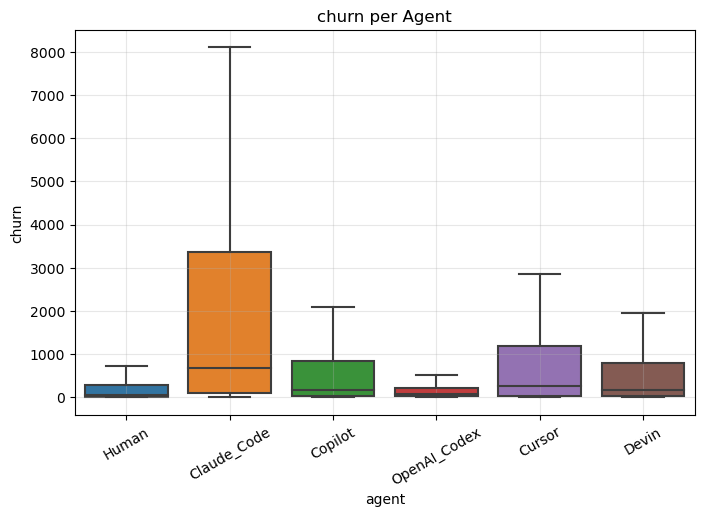

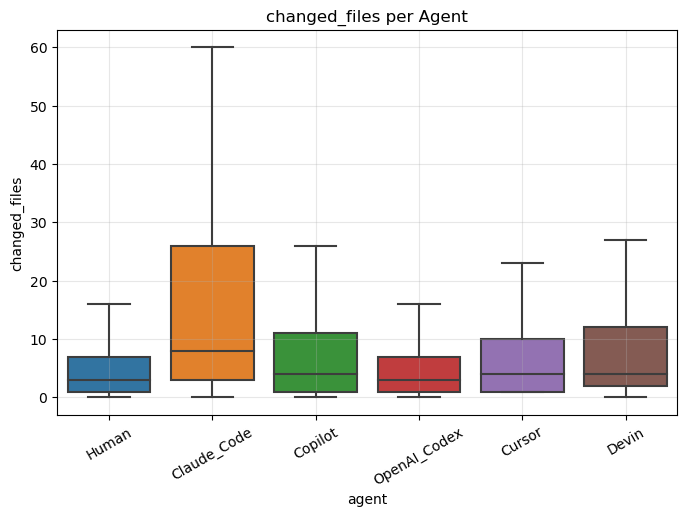

In [54]:
for col in ["additions","deletions","churn","changed_files"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=combined, x="agent", y=col, showfliers=False)
    plt.title(f"{col} per Agent")
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()


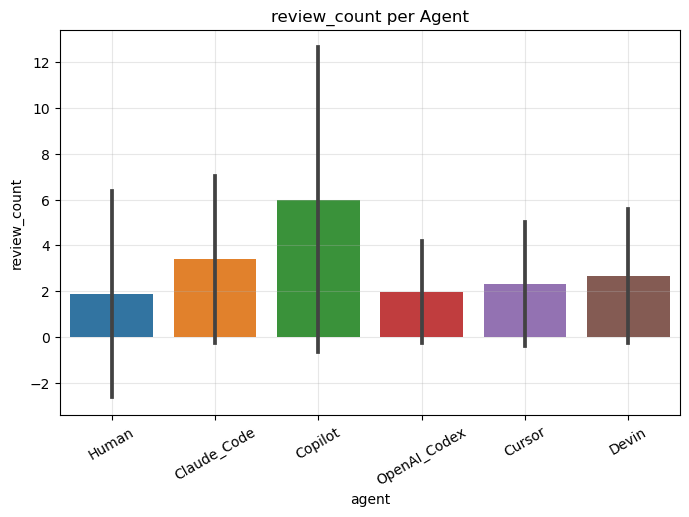

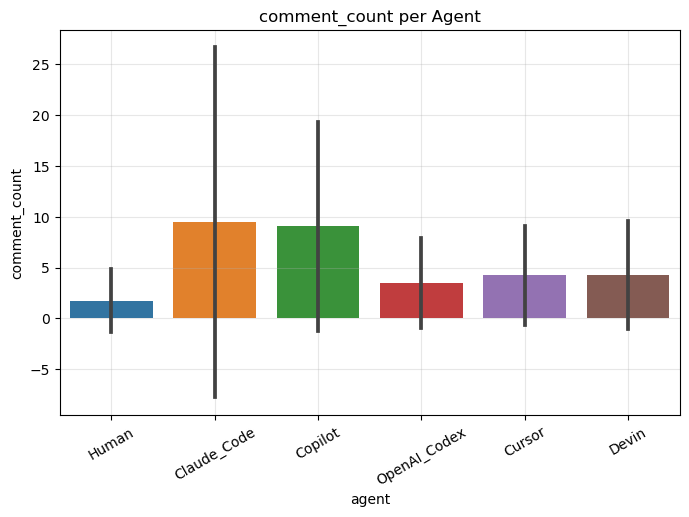

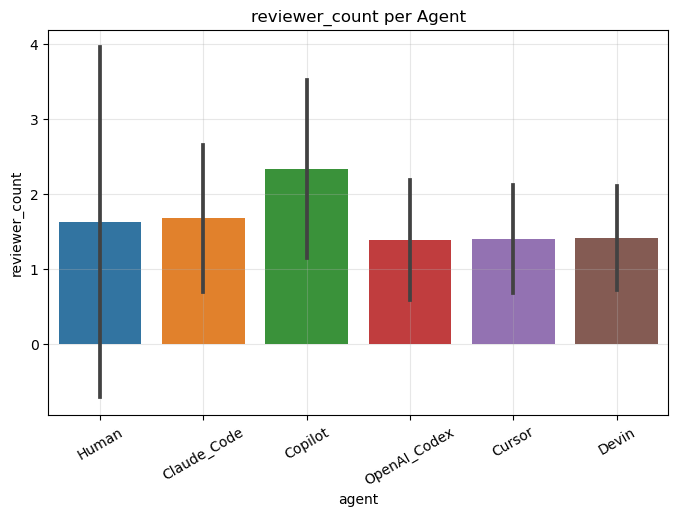

In [55]:
for col in ["review_count","comment_count","reviewer_count"]:
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=combined,
        x="agent", y=col,
        estimator=np.mean, errorbar=("sd",1)
    )
    plt.title(f"{col} per Agent")
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()


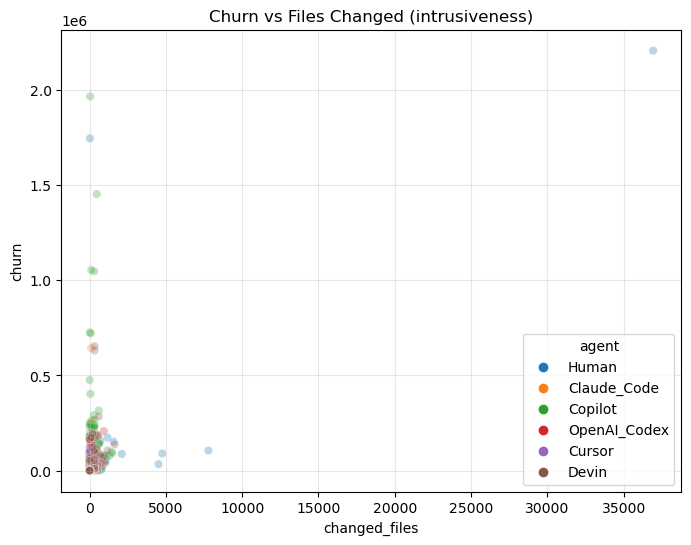

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=combined,
    x="changed_files",
    y="churn",
    hue="agent",
    alpha=0.3
)
plt.title("Churn vs Files Changed (intrusiveness)")
plt.grid(alpha=0.3)
plt.show()


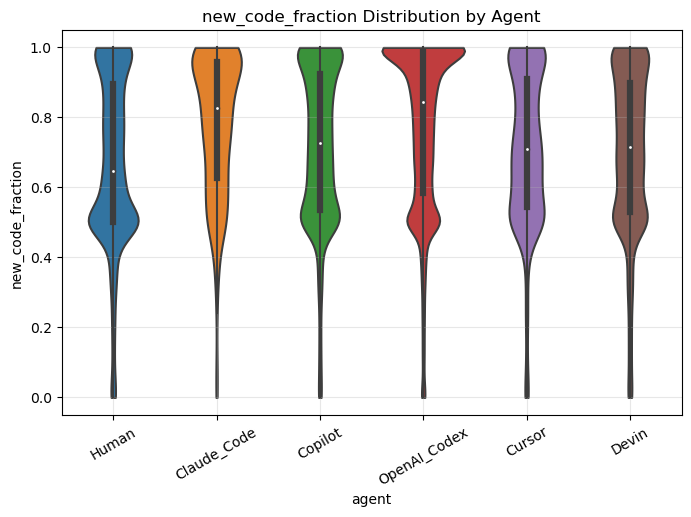

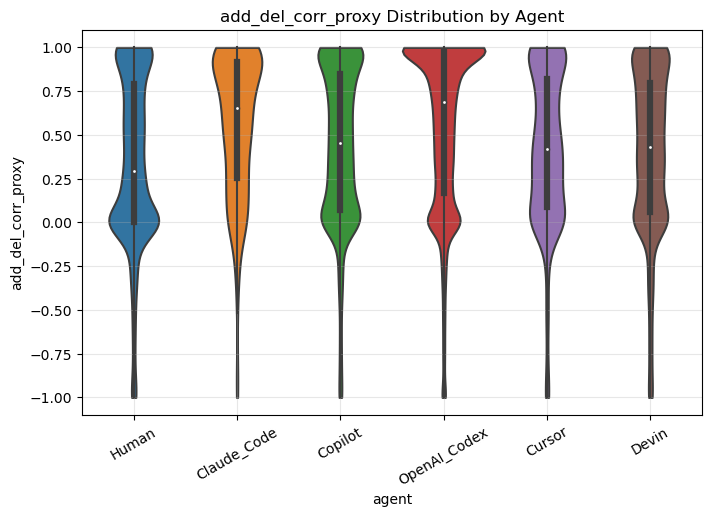

In [57]:
for col in ["new_code_fraction", "add_del_corr_proxy"]:
    plt.figure(figsize=(8,5))
    sns.violinplot(data=combined, x="agent", y=col, cut=0)
    plt.title(f"{col} Distribution by Agent")
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()


In [58]:
def compare(metric):
    h = combined[combined["source_type"]=="Human"][metric].dropna()
    a = combined[combined["source_type"]=="AI_Agent"][metric].dropna()
    u,p = stats.mannwhitneyu(h,a)
    print(f"{metric}: Human={h.mean():.1f}, AI={a.mean():.1f}, p={p:.3e}")

for m in metrics:
    compare(m)


additions: Human=1132.2, AI=1286.4, p=2.014e-79
deletions: Human=1013.5, AI=686.8, p=3.820e-01
churn: Human=2145.7, AI=1973.2, p=2.305e-54
changed_files: Human=26.1, AI=17.2, p=8.800e-11
commit_count: Human=5.9, AI=2.6, p=1.312e-128
review_count: Human=1.9, AI=3.5, p=0.000e+00
comment_count: Human=1.7, AI=6.0, p=0.000e+00
reviewer_count: Human=1.6, AI=1.7, p=8.684e-111
new_code_fraction: Human=0.7, AI=0.7, p=1.608e-123
add_del_corr_proxy: Human=0.3, AI=0.5, p=1.608e-123


In [59]:
agents = combined["agent"].unique()

def compare_agents(metric, a1, a2):
    x = combined[combined["agent"]==a1][metric].dropna()
    y = combined[combined["agent"]==a2][metric].dropna()
    u,p = stats.mannwhitneyu(x,y)
    print(f"{a1} vs {a2} — {metric}: p={p:.3e}")

for a1 in agents:
    for a2 in agents:
        if a1 < a2:
            for m in metrics:
                compare_agents(m, a1, a2)


Human vs OpenAI_Codex — additions: p=6.692e-36
Human vs OpenAI_Codex — deletions: p=7.028e-37
Human vs OpenAI_Codex — churn: p=5.302e-16
Human vs OpenAI_Codex — changed_files: p=5.415e-02
Human vs OpenAI_Codex — commit_count: p=0.000e+00
Human vs OpenAI_Codex — review_count: p=4.395e-107
Human vs OpenAI_Codex — comment_count: p=1.242e-109
Human vs OpenAI_Codex — reviewer_count: p=8.580e-18
Human vs OpenAI_Codex — new_code_fraction: p=2.093e-179
Human vs OpenAI_Codex — add_del_corr_proxy: p=2.093e-179
Claude_Code vs Human — additions: p=7.933e-81
Claude_Code vs Human — deletions: p=2.479e-35
Claude_Code vs Human — churn: p=6.211e-73
Claude_Code vs Human — changed_files: p=1.840e-39
Claude_Code vs Human — commit_count: p=2.552e-12
Claude_Code vs Human — review_count: p=5.661e-31
Claude_Code vs Human — comment_count: p=1.383e-36
Claude_Code vs Human — reviewer_count: p=2.836e-07
Claude_Code vs Human — new_code_fraction: p=1.166e-19
Claude_Code vs Human — add_del_corr_proxy: p=1.166e-19
Cl

In [60]:
import pandas as pd
import numpy as np

metrics = [
    "additions","deletions","churn",
    "changed_files","commit_count",
    "review_count","comment_count","reviewer_count",
    "new_code_fraction","add_del_corr_proxy",
]

# Multi-index summary
summary_by_agent = (
    combined
    .groupby("agent")[metrics]
    .agg(["count","mean","median","std"])
)

# Flatten multi-index columns: ('additions','mean') -> 'additions_mean'
summary_by_agent.columns = [
    f"{metric}_{stat}" for metric, stat in summary_by_agent.columns.to_flat_index()
]

# Optional: order columns (put *_count first, then means)
ordered_cols = sorted(summary_by_agent.columns, key=lambda c: (c.split("_")[-1], c))
summary_by_agent = summary_by_agent[ordered_cols]

# Round for readability
summary_by_agent_rounded = summary_by_agent.round(2)

# LaTeX string (booktabs for nicer tables)
latex_table_agent = summary_by_agent_rounded.to_latex(
    buf=None,
    index=True,
    escape=True,
    na_rep="--",
    column_format="l" + "r" * len(summary_by_agent_rounded.columns),
    bold_rows=True,
    caption="Résumé statistique des métriques de qualité des PR par agent.",
    label="tab:rq1_agent_summary",
    longtable=False
)

print(latex_table_agent)

# Optionally write to file:
with open("table_rq1_agent_summary.tex", "w", encoding="utf-8") as f:
    f.write(latex_table_agent)


\begin{table}
\caption{Résumé statistique des métriques de qualité des PR par agent.}
\label{tab:rq1_agent_summary}
\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & add\_del\_corr\_proxy\_count & additions\_count & changed\_files\_count & churn\_count & comment\_count\_count & commit\_count\_count & deletions\_count & new\_code\_fraction\_count & review\_count\_count & reviewer\_count\_count & add\_del\_corr\_proxy\_mean & additions\_mean & changed\_files\_mean & churn\_mean & comment\_count\_mean & commit\_count\_mean & deletions\_mean & new\_code\_fraction\_mean & review\_count\_mean & reviewer\_count\_mean & add\_del\_corr\_proxy\_median & additions\_median & changed\_files\_median & churn\_median & comment\_count\_median & commit\_count\_median & deletions\_median & new\_code\_fraction\_median & review\_count\_median & reviewer\_count\_median & add\_del\_corr\_proxy\_std & additions\_std & changed\_files\_std & churn\_std & comment\_count\_std & commit\_count\

In [61]:
key_metrics = [
    "churn",
    "changed_files",
    "review_count",
    "comment_count",
    "reviewer_count",
    "new_code_fraction",
]

mean_by_agent = (
    combined
    .groupby("agent")[key_metrics]
    .mean()
    .round(2)
)

latex_table_means = mean_by_agent.to_latex(
    buf=None,
    index=True,
    escape=True,
    na_rep="--",
    column_format="l" + "r" * len(key_metrics),
    bold_rows=True,
    caption="Moyenne des métriques de qualité par agent (RQ1).",
    label="tab:rq1_agent_means",
)

print(latex_table_means)

with open("table_rq1_agent_means.tex", "w", encoding="utf-8") as f:
    f.write(latex_table_means)


\begin{table}
\caption{Moyenne des métriques de qualité par agent (RQ1).}
\label{tab:rq1_agent_means}
\begin{tabular}{lrrrrrr}
\toprule
 & churn & changed\_files & review\_count & comment\_count & reviewer\_count & new\_code\_fraction \\
agent &  &  &  &  &  &  \\
\midrule
\textbf{Claude\_Code} & 8646.950000 & 34.140000 & 3.390000 & 9.440000 & 1.680000 & 0.780000 \\
\textbf{Copilot} & 5538.910000 & 26.840000 & 6.000000 & 9.070000 & 2.340000 & 0.720000 \\
\textbf{Cursor} & 2861.630000 & 18.360000 & 2.310000 & 4.220000 & 1.410000 & 0.710000 \\
\textbf{Devin} & 2680.780000 & 26.560000 & 2.670000 & 4.280000 & 1.420000 & 0.700000 \\
\textbf{Human} & 2145.720000 & 26.050000 & 1.860000 & 1.740000 & 1.630000 & 0.670000 \\
\textbf{OpenAI\_Codex} & 800.890000 & 12.420000 & 1.970000 & 3.460000 & 1.390000 & 0.770000 \\
\bottomrule
\end{tabular}
\end{table}



In [62]:
metrics_h = [
    "churn",
    "changed_files",
    "commit_count",
    "review_count",
    "comment_count",
    "reviewer_count",
    "new_code_fraction",
]

summary_human_ai = (
    combined
    .groupby("source_type")[metrics_h]
    .agg(["count","mean","median","std"])
)

summary_human_ai.columns = [
    f"{metric}_{stat}" for metric, stat in summary_human_ai.columns.to_flat_index()
]
summary_human_ai = summary_human_ai.round(2)

latex_table_human_ai = summary_human_ai.to_latex(
    buf=None,
    index=True,
    escape=True,
    na_rep="--",
    column_format="l" + "r" * len(summary_human_ai.columns),
    bold_rows=True,
    caption="Comparaison des métriques de qualité entre PR humaines et PR générées par agents IA.",
    label="tab:rq1_human_vs_ai",
)

print(latex_table_human_ai)

with open("table_rq1_human_vs_ai.tex", "w", encoding="utf-8") as f:
    f.write(latex_table_human_ai)


\begin{table}
\caption{Comparaison des métriques de qualité entre PR humaines et PR générées par agents IA.}
\label{tab:rq1_human_vs_ai}
\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & churn\_count & churn\_mean & churn\_median & churn\_std & changed\_files\_count & changed\_files\_mean & changed\_files\_median & changed\_files\_std & commit\_count\_count & commit\_count\_mean & commit\_count\_median & commit\_count\_std & review\_count\_count & review\_count\_mean & review\_count\_median & review\_count\_std & comment\_count\_count & comment\_count\_mean & comment\_count\_median & comment\_count\_std & reviewer\_count\_count & reviewer\_count\_mean & reviewer\_count\_median & reviewer\_count\_std & new\_code\_fraction\_count & new\_code\_fraction\_mean & new\_code\_fraction\_median & new\_code\_fraction\_std \\
source_type &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\textbf{AI\_Agent} & 33580 & 1973.180000 & 95.000000 & 20

In [63]:
rows = []
for m in metrics_h:
    h = combined.loc[combined["source_type"]=="Human", m].dropna()
    a = combined.loc[combined["source_type"]=="AI_Agent", m].dropna()
    if len(h) == 0 or len(a) == 0:
        continue
    diff = a.mean() - h.mean()
    rows.append({
        "metric": m,
        "mean_human": h.mean(),
        "mean_ai": a.mean(),
        "diff_ai_minus_human": diff,
    })

effect_df = pd.DataFrame(rows).set_index("metric").round(2)

latex_effect = effect_df.to_latex(
    buf=None,
    index=True,
    escape=True,
    na_rep="--",
    column_format="lrrr",
    bold_rows=True,
    caption="Différence de moyenne des métriques clé entre PR humaines et PR IA (AI − Human).",
    label="tab:rq1_effect_human_ai",
)

print(latex_effect)

with open("table_rq1_effect_human_ai.tex", "w", encoding="utf-8") as f:
    f.write(latex_effect)


\begin{table}
\caption{Différence de moyenne des métriques clé entre PR humaines et PR IA (AI − Human).}
\label{tab:rq1_effect_human_ai}
\begin{tabular}{lrrr}
\toprule
 & mean\_human & mean\_ai & diff\_ai\_minus\_human \\
metric &  &  &  \\
\midrule
\textbf{churn} & 2145.720000 & 1973.180000 & -172.540000 \\
\textbf{changed\_files} & 26.050000 & 17.150000 & -8.900000 \\
\textbf{commit\_count} & 5.860000 & 2.640000 & -3.220000 \\
\textbf{review\_count} & 1.860000 & 3.550000 & 1.690000 \\
\textbf{comment\_count} & 1.740000 & 6.020000 & 4.280000 \\
\textbf{reviewer\_count} & 1.630000 & 1.720000 & 0.090000 \\
\textbf{new\_code\_fraction} & 0.670000 & 0.750000 & 0.080000 \\
\bottomrule
\end{tabular}
\end{table}

